# Construcción de la red bipartita autor-video


**Definición de la red:**
- Un conjunto de nodos son **autores** (author_channel_id), el otro son **videos** (video_id).
- Existe una arista entre un autor y un video si ese autor publicó al menos un comentario en ese video.
- El **peso** de la arista es el número de comentarios que ese autor escribió en ese video.
- La red es **bipartita**: nunca hay aristas autor-autor ni video-video en este grafo.

In [1]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np

pd.set_option('display.max_columns', None)

## 1. Carga de los datos limpios

Se parte de los archivos ya integrados y limpiados en los puntos 1 y 2 del laboratorio.

In [2]:
comments = pd.read_csv('youtube_comments_clean.csv')
videos = pd.read_csv('youtube_videos_clean.csv')

print(f"Comentarios: {comments.shape[0]} filas, {comments.shape[1]} columnas")
print(f"Videos: {videos.shape[0]} filas, {videos.shape[1]} columnas")
print(f"Autores únicos que comentaron: {comments['author_channel_id'].nunique()}")
print(f"Videos con al menos un comentario: {comments['video_id'].nunique()}")

Comentarios: 406 filas, 24 columnas
Videos: 293 filas, 21 columnas
Autores únicos que comentaron: 332
Videos con al menos un comentario: 19


## 2. Construcción de la tabla de aristas

Cada arista corresponde a un par único (`author_channel_id`, `video_id`). El peso es el
conteo de comentarios de ese autor en ese video. Adicionalmente se guarda la suma de
`like_count` de esos comentarios como atributo descriptivo de la arista (no como parte
de la definición del peso, que el enunciado fija como número de comentarios).

In [3]:
edges_df = (
    comments
    .groupby(['author_channel_id', 'video_id'], as_index=False)
    .agg(
        weight=('comment_id', 'count'),
        likes_totales=('like_count', 'sum'),
    )
)
edges_df['tipo_arista'] = 'autor_comento_video'

print(f"Número de aristas (pares autor-video únicos): {edges_df.shape[0]}")
print(f"Suma de pesos == total de comentarios: {edges_df['weight'].sum() == len(comments)}")
print(f"Distribución del peso de las aristas:")
print(edges_df['weight'].value_counts().sort_index())

edges_df.head()

Número de aristas (pares autor-video únicos): 343
Suma de pesos == total de comentarios: True
Distribución del peso de las aristas:
weight
1    303
2     28
3      7
4      1
5      2
6      2
Name: count, dtype: int64


,author_channel_id,video_id,weight,likes_totales,tipo_arista
0,UC-HeUTT6_g-VoiWds2a4H-w,6W4u8sGEnGM,1,0,autor_comento_video
1,UC-Iul5tDYH_oiAMXQH-KaaQ,6W4u8sGEnGM,1,1,autor_comento_video
2,UC-QOpE7GOxlXcHZ8b7HbQKA,OkXlHx0hx-8,2,0,autor_comento_video
3,UC-fiZBS5Gp1eCJd9ucgWnCg,j43HgwYFKfk,1,6,autor_comento_video
4,UC-hfX8J5JPJ-dfuakzegMLA,n8iP75gIpmw,1,6,autor_comento_video


## 3. Construcción del grafo bipartito

Se agregan primero todos los nodos autor y todos los nodos video (con sus atributos),
y luego las aristas con su peso. Cada nodo lleva el atributo `bipartite` para identificar
a qué conjunto pertenece.

In [4]:
B = nx.Graph()

# --- nodos autor ---
autores_info = comments[['author_channel_id', 'author_name']].drop_duplicates()
for _, row in autores_info.iterrows():
    B.add_node(
        row['author_channel_id'],
        bipartite='autor',
        label=row['author_name'],
    )

# --- nodos video (solo los videos que efectivamente tienen comentarios) ---
videos_comentados = videos[videos['video_id'].isin(comments['video_id'])].copy()
for _, row in videos_comentados.iterrows():
    B.add_node(
        row['video_id'],
        bipartite='video',
        label=row['title'],
        channel_name=row['channel_name'],
        channel_id=row['channel_id'],
        category=row['category'],
        view_count=row['view_count'],
    )

# --- aristas ---
for _, row in edges_df.iterrows():
    B.add_edge(
        row['author_channel_id'], row['video_id'],
        weight=int(row['weight']),
        likes_totales=int(row['likes_totales']),
    )

print(f"Nodos totales: {B.number_of_nodes()}")
print(f"Aristas totales: {B.number_of_edges()}")
print(f"¿Es bipartito?: {nx.is_bipartite(B)}")

Nodos totales: 351
Aristas totales: 343
¿Es bipartito?: True


In [5]:
autor_nodes = [n for n, d in B.nodes(data=True) if d['bipartite'] == 'autor']
video_nodes = [n for n, d in B.nodes(data=True) if d['bipartite'] == 'video']

print(f"Nodos tipo autor: {len(autor_nodes)}")
print(f"Nodos tipo video: {len(video_nodes)}")
print(f"Total de comentarios en dataset original: {len(comments)} -> coincide con suma de pesos de aristas")

Nodos tipo autor: 332
Nodos tipo video: 19
Total de comentarios en dataset original: 406 -> coincide con suma de pesos de aristas


## 4. Tabla de nodos y tabla de aristas

Se entregan ambas tablas en un único DataFrame de nodos (columna `tipo` distingue autor/video)
y un DataFrame de aristas independiente, junto con sus versiones exportadas a CSV.

In [6]:
grado = dict(B.degree())
grado_ponderado = dict(B.degree(weight='weight'))

filas_nodos = []
for n, d in B.nodes(data=True):
    filas_nodos.append({
        'node_id': n,
        'tipo': d['bipartite'],
        'label': d.get('label'),
        'grado': grado[n],
        'peso_total': grado_ponderado[n],
        'channel_name': d.get('channel_name'),
        'category': d.get('category'),
        'view_count': d.get('view_count'),
    })

nodes_df = pd.DataFrame(filas_nodos)

print("Resumen de nodos por tipo:")
print(nodes_df['tipo'].value_counts())
print()
print("Nodos con mayor peso total (videos más comentados / autores más activos):")
nodes_df.sort_values('peso_total', ascending=False).head(10)

Resumen de nodos por tipo:
tipo
autor    332
video     19
Name: count, dtype: int64

Nodos con mayor peso total (videos más comentados / autores más activos):


,node_id,tipo,label,grado,peso_total,channel_name,category,view_count
346,n8iP75gIpmw,video,Qué rico come tu diputado,128,161,Quorum,News & Politics,11775.0
344,j43HgwYFKfk,video,La cooptación de Walter Mazariegos en la USAC,49,50,Quorum,News & Politics,10156.0
334,6W4u8sGEnGM,video,Inician los trabajos de recuperación del Puent...,32,45,Gobierno de la República de Guatemala,Entertainment,11670.0
336,OkXlHx0hx-8,video,EE.UU. envía a mexicanos deportados a Guatemal...,18,25,Noticias Telemundo,News & Politics,14200.0
345,lj983NWyAQY,video,Plan 2032 Ciudad de Guatemala,25,25,Municipalidad de Guatemala,News & Politics,304089.0
337,PjmxCj-a9Hg,video,Conferencia de Prensa del Gobierno de Guatemal...,19,25,Gobierno de la República de Guatemala,Entertainment,3628.0
349,yLZS3JiEBg8,video,Arroz con pollo a la MONOPOLIO,16,16,Quorum,News & Politics,1954.0
332,06mFNPU0aB8,video,Capturan a presuntos delincuentes disfrazados ...,13,14,Noti7,News & Politics,6692.0
347,ndAZjHqzzT8,video,Internet: escoger el menos malo,10,12,Quorum,News & Politics,717.0
343,is3Mk5oC19g,video,Capturan a ladrón que había quedado grabado mi...,7,7,TN23 Guatemala,News & Politics,4616.0


In [7]:
edges_df.rename(columns={'author_channel_id': 'source', 'video_id': 'target'}, inplace=True)

print("Tabla de aristas (primeras filas):")
edges_df.head(10)

Tabla de aristas (primeras filas):


,source,target,weight,likes_totales,tipo_arista
0,UC-HeUTT6_g-VoiWds2a4H-w,6W4u8sGEnGM,1,0,autor_comento_video
1,UC-Iul5tDYH_oiAMXQH-KaaQ,6W4u8sGEnGM,1,1,autor_comento_video
2,UC-QOpE7GOxlXcHZ8b7HbQKA,OkXlHx0hx-8,2,0,autor_comento_video
3,UC-fiZBS5Gp1eCJd9ucgWnCg,j43HgwYFKfk,1,6,autor_comento_video
4,UC-hfX8J5JPJ-dfuakzegMLA,n8iP75gIpmw,1,6,autor_comento_video
5,UC-jS_kA9w-OmpupXDx156Rg,n8iP75gIpmw,1,2,autor_comento_video
6,UC-pNP6RMFuLg_-x7Ah_0kEA,n8iP75gIpmw,1,5,autor_comento_video
7,UC094EFEmMSdwVa8NQjjYBXg,b_Hkrkl3adA,1,0,autor_comento_video
8,UC0HvfEWozTHbwl_iEmJNvVA,6W4u8sGEnGM,1,3,autor_comento_video
9,UC0RpuMwkDKJYqgKHtsJRuWQ,lj983NWyAQY,1,113,autor_comento_video


In [8]:
nodes_df.to_csv('red_bipartita_nodos.csv', index=False)
edges_df.to_csv('red_bipartita_aristas.csv', index=False)
print("Tablas exportadas: red_bipartita_nodos.csv, red_bipartita_aristas.csv")

Tablas exportadas: red_bipartita_nodos.csv, red_bipartita_aristas.csv


## 5. Visualización de la red completa

Se visualizan **todos** los nodos y aristas (332 autores + 19 videos), sin filtrar ni podar
la red por estética. Para que la lectura sea posible:
- Los videos (hub) se dibujan más grandes, en rojo, y con su título como etiqueta.
- Los autores se dibujan pequeños, en azul, sin etiqueta individual (serían 332 etiquetas ilegibles).
- El grosor/transparencia de las aristas es bajo porque la mayoría tiene peso 1.

Esto no elimina estructura: cada nodo y cada arista de la red original sigue presente en el dibujo.

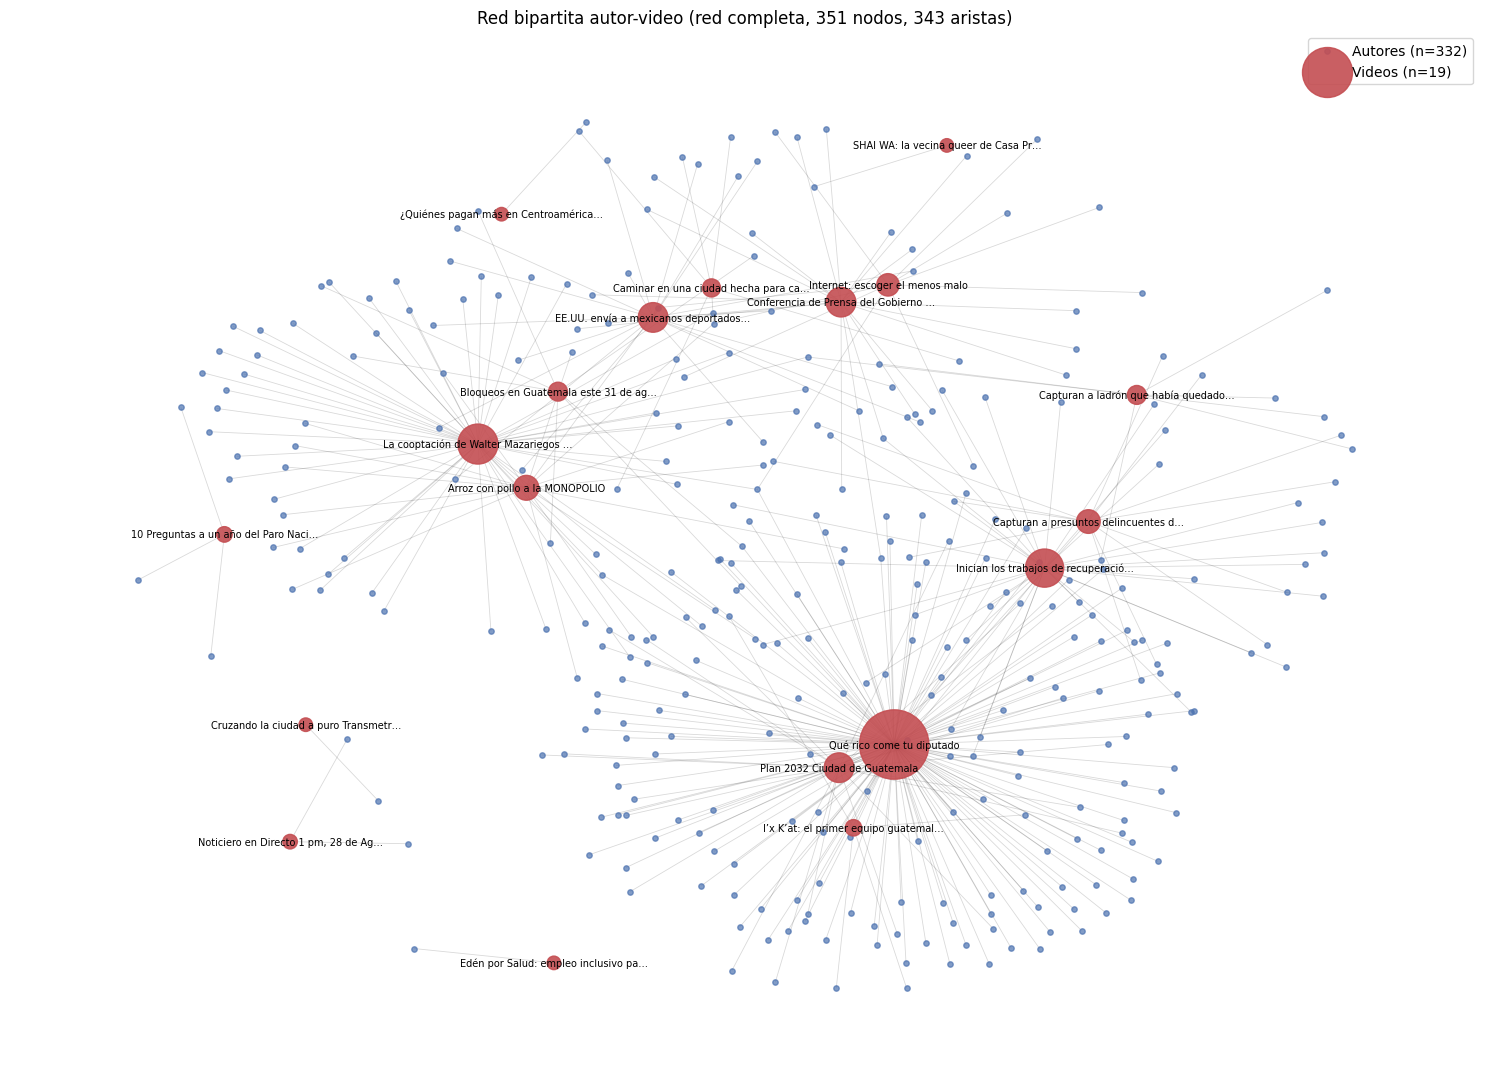

In [9]:
pos = nx.spring_layout(B, k=0.25, seed=42, weight='weight')

video_sizes = [80 + 15 * B.degree(n, weight='weight') for n in video_nodes]

fig, ax = plt.subplots(figsize=(15, 11))
nx.draw_networkx_edges(B, pos, alpha=0.15, width=0.6, ax=ax)
nx.draw_networkx_nodes(B, pos, nodelist=autor_nodes, node_color='#4C72B0',
                        node_size=15, alpha=0.7, label=f'Autores (n={len(autor_nodes)})', ax=ax)
nx.draw_networkx_nodes(B, pos, nodelist=video_nodes, node_color='#C44E52',
                        node_size=video_sizes, alpha=0.9, label=f'Videos (n={len(video_nodes)})', ax=ax)

labels = {n: (B.nodes[n]['label'][:35] + '…' if len(B.nodes[n]['label']) > 35 else B.nodes[n]['label'])
          for n in video_nodes}
nx.draw_networkx_labels(B, pos, labels=labels, font_size=7, ax=ax)

ax.legend(scatterpoints=1, loc='upper right')
ax.set_title('Red bipartita autor-video (red completa, 351 nodos, 343 aristas)')
ax.axis('off')
plt.tight_layout()
plt.savefig('red_bipartita_completa.png', dpi=150)
plt.show()

## 5. Proyecciones de la red

### 5.1. Proyección autor-autor

Dos autores quedan conectados si comentaron en al menos un mismo video; el peso es el número de videos que
comentaron en común.


In [10]:
G_autores = nx.bipartite.weighted_projected_graph(B, autor_nodes, ratio=False)

grado_autores = dict(G_autores.degree())
aislados_autores = [n for n, g in grado_autores.items() if g == 0]
pesos_autores = [d["weight"] for _, _, d in G_autores.edges(data=True)]

print(f"Nodos (autores): {G_autores.number_of_nodes()}")
print(f"Aristas:         {G_autores.number_of_edges()}")
print(f"Densidad:        {nx.density(G_autores):.4f}")
print(f"Autores aislados (no comparten ningún video con otro autor): {len(aislados_autores)} / {len(autor_nodes)}")
print(f"Distribución del peso (videos compartidos): {pd.Series(pesos_autores).value_counts().sort_index().to_dict()}")
print()
print("Pares de autores con más videos compartidos:")
top_pares = sorted(G_autores.edges(data=True), key=lambda e: -e[2]["weight"])[:5]
for u, v, d in top_pares:
    print(f"  {B.nodes[u]['label']}  <->  {B.nodes[v]['label']}   peso={d['weight']}")


Nodos (autores): 332
Aristas:         10732
Densidad:        0.1953
Autores aislados (no comparten ningún video con otro autor): 4 / 332
Distribución del peso (videos compartidos): {1: 10730, 2: 2}

Pares de autores con más videos compartidos:
  @hashojea7348  <->  @Alejandro00710   peso=2
  @inge_vergueta  <->  @Jel.Awesh.M   peso=2
  @MarcosCarillo-b1r  <->  @javiercifuentesarchila6041   peso=1
  @MarcosCarillo-b1r  <->  @caminoseternos752   peso=1
  @MarcosCarillo-b1r  <->  @armindapenados2841   peso=1


### 5.2. Proyección video-video

Dos videos quedan conectados si comparten al menos un autor que comentó en ambos; el peso es el número de autores
en común.


In [11]:
G_videos = nx.bipartite.weighted_projected_graph(B, video_nodes, ratio=False)

grado_videos = dict(G_videos.degree())
aislados_videos = [n for n, g in grado_videos.items() if g == 0]
pesos_videos = [d["weight"] for _, _, d in G_videos.edges(data=True)]

print(f"Nodos (videos): {G_videos.number_of_nodes()}")
print(f"Aristas:        {G_videos.number_of_edges()}")
print(f"Densidad:       {nx.density(G_videos):.4f}")
print(f"Videos aislados (sin autores compartidos con ningún otro video): {len(aislados_videos)} / {len(video_nodes)}")
print(f"Distribución del peso (autores compartidos): {pd.Series(pesos_videos).value_counts().sort_index().to_dict() if pesos_videos else {}}")
print()
print("Componentes conexas:", nx.number_connected_components(G_videos),
      "-> tamaños:", sorted([len(c) for c in nx.connected_components(G_videos)], reverse=True))
print()
print("Pares de videos con más autores compartidos:")
top_pares_v = sorted(G_videos.edges(data=True), key=lambda e: -e[2]["weight"])[:5]
for u, v, d in top_pares_v:
    print(f"  {B.nodes[u]['label'][:45]}  <->  {B.nodes[v]['label'][:45]}   peso={d['weight']}")


Nodos (videos): 19
Aristas:        11
Densidad:       0.0643
Videos aislados (sin autores compartidos con ningún otro video): 9 / 19
Distribución del peso (autores compartidos): {1: 9, 2: 2}

Componentes conexas: 10 -> tamaños: [10, 1, 1, 1, 1, 1, 1, 1, 1, 1]

Pares de videos con más autores compartidos:
  La cooptación de Walter Mazariegos en la USAC  <->  Qué rico come tu diputado   peso=2
  Internet: escoger el menos malo  <->  Arroz con pollo a la MONOPOLIO   peso=2
  Capturan a presuntos delincuentes disfrazados  <->  Inician los trabajos de recuperación del Puen   peso=1
  Inician los trabajos de recuperación del Puen  <->  Conferencia de Prensa del Gobierno de Guatema   peso=1
  Conferencia de Prensa del Gobierno de Guatema  <->  Qué rico come tu diputado   peso=1


### 5.3. Comparación de las dos proyecciones y fenómeno que representa cada una


In [12]:
comparacion = pd.DataFrame([
    {
        "proyección": "autor-autor",
        "nodos": G_autores.number_of_nodes(),
        "aristas": G_autores.number_of_edges(),
        "densidad": round(nx.density(G_autores), 4),
        "peso_promedio": round(sum(pesos_autores) / len(pesos_autores), 2),
        "peso_máximo": max(pesos_autores),
        "nodos_aislados": len(aislados_autores),
    },
    {
        "proyección": "video-video",
        "nodos": G_videos.number_of_nodes(),
        "aristas": G_videos.number_of_edges(),
        "densidad": round(nx.density(G_videos), 4),
        "peso_promedio": round(sum(pesos_videos) / len(pesos_videos), 2) if pesos_videos else 0,
        "peso_máximo": max(pesos_videos) if pesos_videos else 0,
        "nodos_aislados": len(aislados_videos),
    },
])
comparacion


,proyección,nodos,aristas,densidad,peso_promedio,peso_máximo,nodos_aislados
0,autor-autor,332,10732,0.1953,1.00,2,4
1,video-video,19,11,0.0643,1.18,2,9


In [13]:
# Evidencia del "efecto clique" que produce un video muy comentado en la proyección autor-autor:
# cualquier par de autores que comentó en ese mismo video queda conectado, sin que eso implique
# que interactuaron entre sí.
autores_por_video = edges_df.groupby("target")["source"].nunique().sort_values(ascending=False)
video_top = autores_por_video.index[0]
n_autores_top = autores_por_video.iloc[0]
clique_potencial = n_autores_top * (n_autores_top - 1) // 2

print(f"Video con más autores distintos: '{B.nodes[video_top]['label'][:60]}' ({n_autores_top} autores)")
print(f"Aristas que ese video por sí solo podría generar en G_autores (clique completo): {clique_potencial}")
print(f"Eso representa el {clique_potencial / G_autores.number_of_edges():.1%} de las {G_autores.number_of_edges()} "
      f"aristas totales de la proyección autor-autor.")


Video con más autores distintos: 'Qué rico come tu diputado' (128 autores)
Aristas que ese video por sí solo podría generar en G_autores (clique completo): 8128
Eso representa el 75.7% de las 10732 aristas totales de la proyección autor-autor.


### 5.4. Visualización de cada proyección


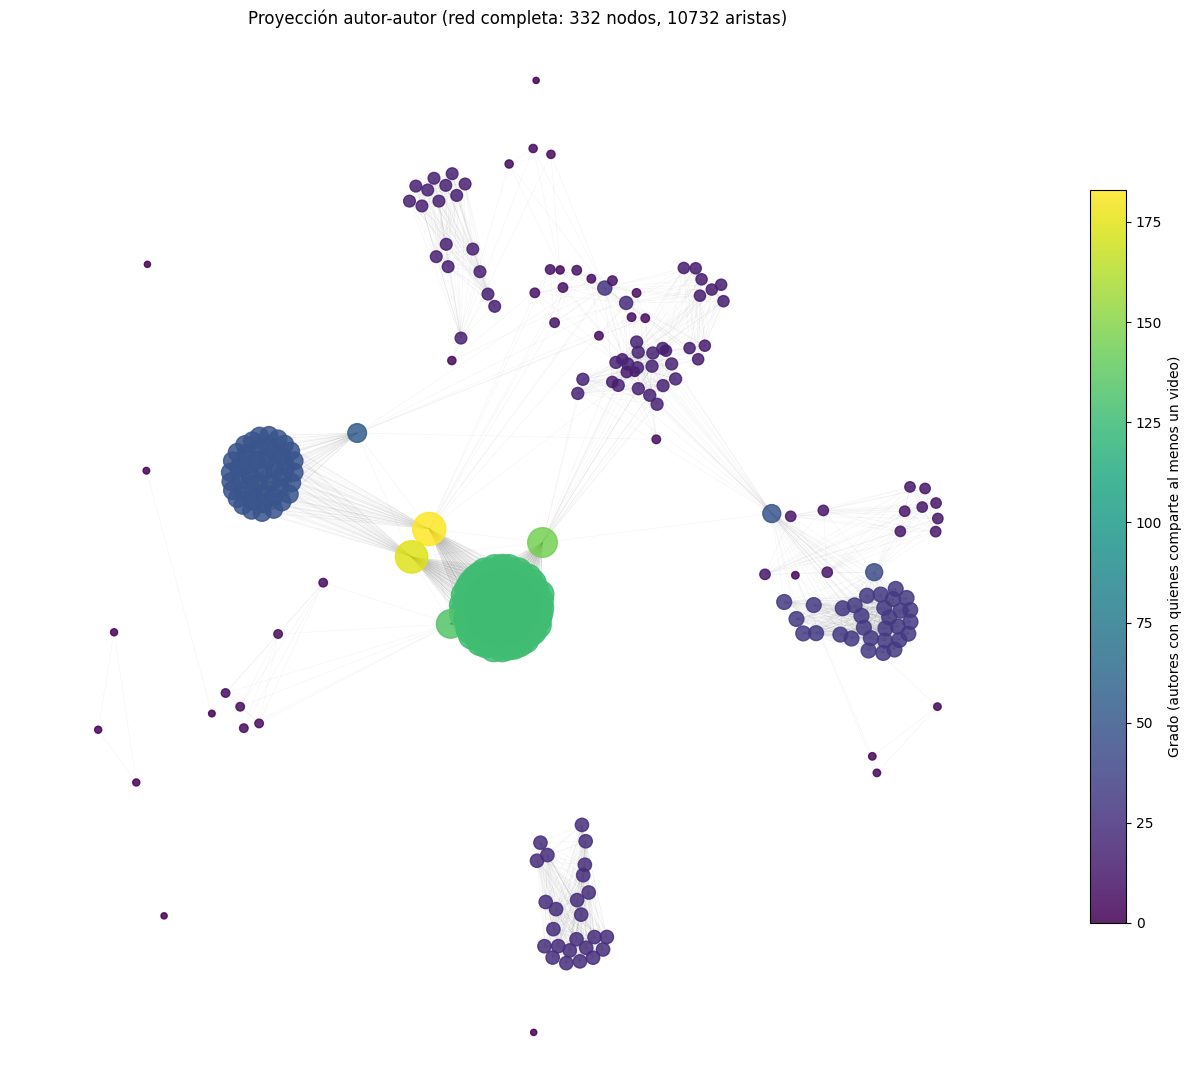

In [14]:
pos_a = nx.spring_layout(G_autores, seed=42, weight="weight", k=0.3)

grados_lista = [grado_autores[n] for n in G_autores.nodes()]

fig, ax = plt.subplots(figsize=(13, 11))
nx.draw_networkx_edges(G_autores, pos_a, alpha=0.04, width=0.5, ax=ax)
nodes_plot = nx.draw_networkx_nodes(
    G_autores, pos_a,
    node_size=[20 + 3 * g for g in grados_lista],
    node_color=grados_lista, cmap="viridis",
    alpha=0.85, ax=ax,
)
plt.colorbar(nodes_plot, ax=ax, label="Grado (autores con quienes comparte al menos un video)", shrink=0.7)
ax.set_title(f"Proyección autor-autor (red completa: {G_autores.number_of_nodes()} nodos, "
             f"{G_autores.number_of_edges()} aristas)")
ax.axis("off")
plt.tight_layout()
plt.savefig("proyeccion_autor_autor.png", dpi=150)
plt.show()


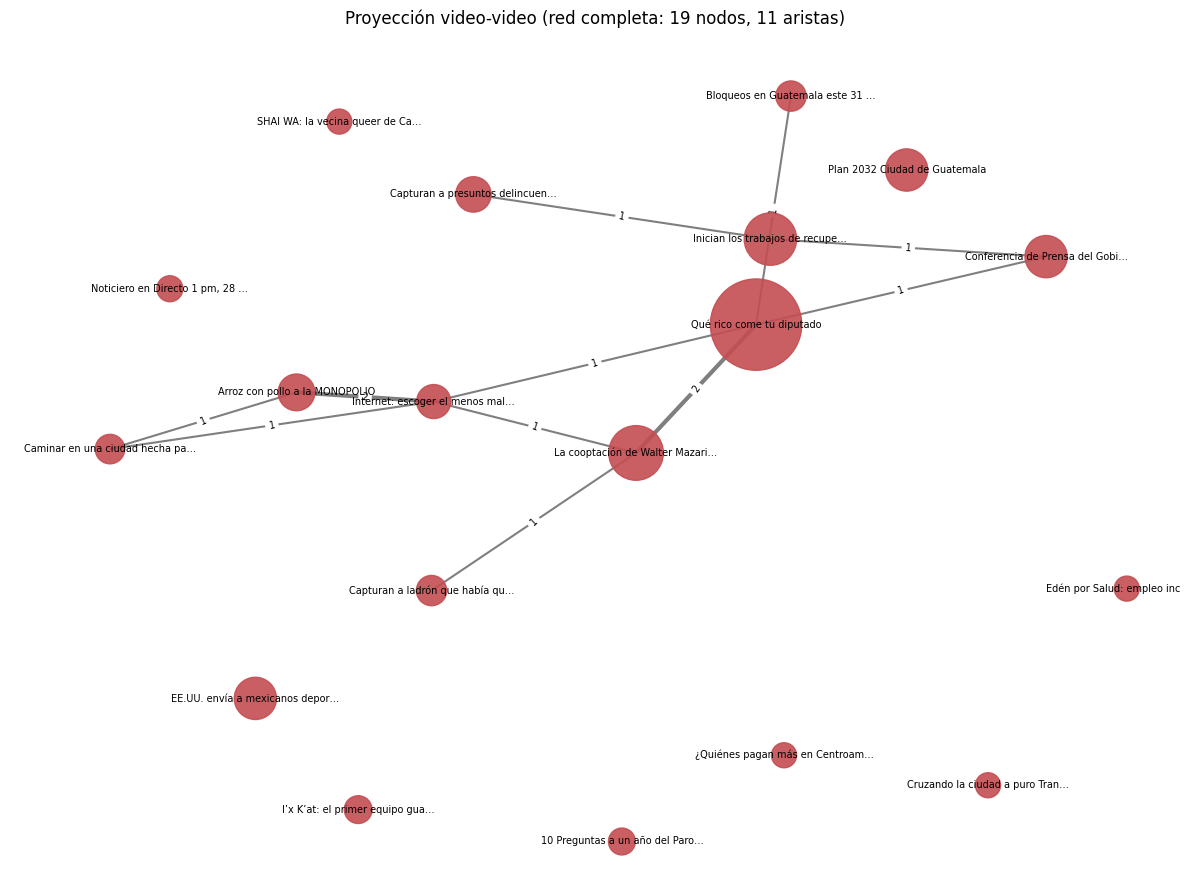

In [15]:
pos_v = nx.spring_layout(G_videos, seed=7, weight="weight", k=0.9)

edge_weights_v = [G_videos[u][v]["weight"] for u, v in G_videos.edges()]
node_sizes_v = [300 + 25 * B.degree(n, weight="weight") for n in G_videos.nodes()]

fig, ax = plt.subplots(figsize=(12, 9))
nx.draw_networkx_edges(G_videos, pos_v, width=[1.5 * w for w in edge_weights_v], alpha=0.5, ax=ax)
nx.draw_networkx_nodes(G_videos, pos_v, node_size=node_sizes_v, node_color="#C44E52", alpha=0.9, ax=ax)

labels_v = {n: (B.nodes[n]["label"][:30] + "…" if len(B.nodes[n]["label"]) > 30 else B.nodes[n]["label"])
            for n in G_videos.nodes()}
nx.draw_networkx_labels(G_videos, pos_v, labels=labels_v, font_size=7, ax=ax)

edge_labels_v = {(u, v): d["weight"] for u, v, d in G_videos.edges(data=True)}
nx.draw_networkx_edge_labels(G_videos, pos_v, edge_labels=edge_labels_v, font_size=7, ax=ax)

ax.set_title(f"Proyección video-video (red completa: {G_videos.number_of_nodes()} nodos, "
             f"{G_videos.number_of_edges()} aristas)")
ax.axis("off")
plt.tight_layout()
plt.savefig("proyeccion_video_video.png", dpi=150)
plt.show()


## 6. Topología y fragmentación


### 6.1. Tamaño, densidad, grado y componentes conexos


In [16]:
def resumen_topologico(G, nombre):
    grados = dict(G.degree())
    componentes = sorted([len(c) for c in nx.connected_components(G)], reverse=True)
    return {
        "red": nombre,
        "nodos": G.number_of_nodes(),
        "aristas": G.number_of_edges(),
        "densidad": round(nx.density(G), 4),
        "grado_medio": round(sum(grados.values()) / len(grados), 2),
        "grado_max": max(grados.values()),
        "n_componentes": len(componentes),
        "tamaño_componente_mayor": componentes[0],
        "%_en_componente_mayor": round(100 * componentes[0] / G.number_of_nodes(), 1),
    }

resumen = pd.DataFrame([
    resumen_topologico(B, "bipartita B"),
    resumen_topologico(G_autores, "proyección autor-autor"),
    resumen_topologico(G_videos, "proyección video-video"),
])
resumen


,red,nodos,aristas,densidad,grado_medio,grado_max,n_componentes,tamaño_componente_mayor,%_en_componente_mayor
0,bipartita B,351,343,0.0056,1.95,128,10,286,81.5
1,proyección autor-autor,332,10732,0.1953,64.65,183,10,276,83.1
2,proyección video-video,19,11,0.0643,1.16,4,10,10,52.6


In [17]:
# La densidad estándar de networkx para B considera todos los pares nodo-nodo posibles (incluyendo
# pares autor-autor y video-video, que nunca pueden tener arista en una red bipartita), por lo que
# subestima artificialmente qué tan "llena" está la red respecto a lo único posible: pares autor-video.
densidad_bipartita_real = B.number_of_edges() / (len(autor_nodes) * len(video_nodes))
print(f"Densidad bipartita real (aristas / (autores x videos)): {densidad_bipartita_real:.4f} "
      f"({B.number_of_edges()} de {len(autor_nodes)*len(video_nodes)} pares autor-video posibles)")
print()

grado_B = dict(B.degree())
grado_autores_B = pd.Series([grado_B[n] for n in autor_nodes])
grado_videos_B = pd.Series([grado_B[n] for n in video_nodes])

print("Grado de los autores en B (a cuántos videos comentó cada uno):")
print(grado_autores_B.value_counts().sort_index())
print(f"-> {(grado_autores_B == 1).mean():.1%} de los autores comentó en un solo video (grado 1).")
print()
print("Grado de los videos en B (a cuántos autores distintos recibió cada uno), ordenado:")
print(grado_videos_B.sort_values(ascending=False).values)


Densidad bipartita real (aristas / (autores x videos)): 0.0544 (343 de 6308 pares autor-video posibles)

Grado de los autores en B (a cuántos videos comentó cada uno):
1    323
2      7
3      2
Name: count, dtype: int64
-> 97.3% de los autores comentó en un solo video (grado 1).

Grado de los videos en B (a cuántos autores distintos recibió cada uno), ordenado:
[128  49  32  25  19  18  16  13  10   7   7   6   4   3   2   1   1   1
   1]


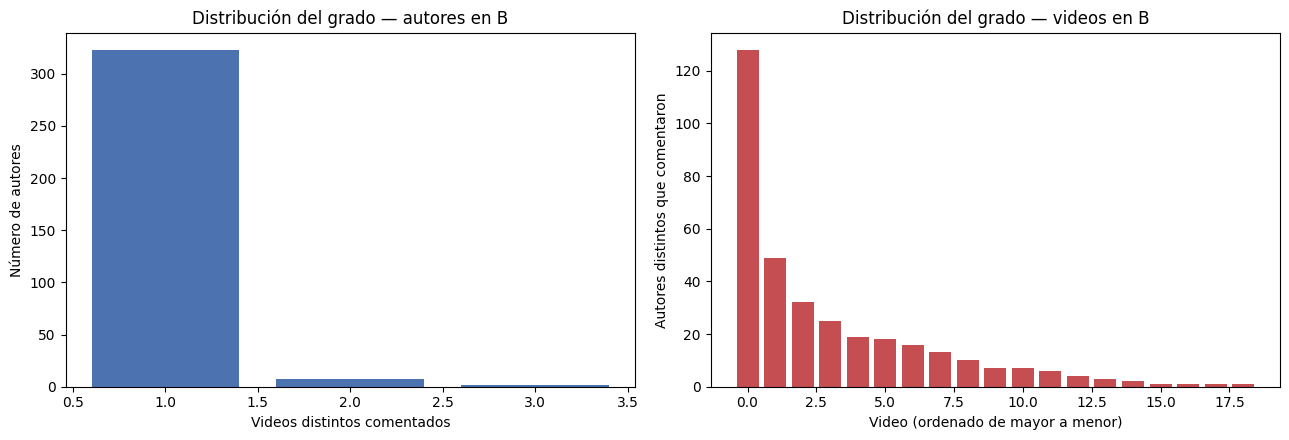

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].bar(grado_autores_B.value_counts().sort_index().index,
            grado_autores_B.value_counts().sort_index().values, color="#4C72B0")
axes[0].set_title("Distribución del grado — autores en B")
axes[0].set_xlabel("Videos distintos comentados")
axes[0].set_ylabel("Número de autores")

axes[1].bar(range(len(video_nodes)), grado_videos_B.sort_values(ascending=False).values, color="#C44E52")
axes[1].set_title("Distribución del grado — videos en B")
axes[1].set_xlabel("Video (ordenado de mayor a menor)")
axes[1].set_ylabel("Autores distintos que comentaron")

plt.tight_layout()
plt.savefig("distribucion_grados_B.png", dpi=150)
plt.show()


### 6.2. Cohesión y transitividad


In [19]:
# Transitividad clásica: en una red bipartita es SIEMPRE 0 por definición, porque no puede haber
# triángulos (todo ciclo en un grafo bipartito tiene longitud par >= 4). No es un hallazgo, es una
# propiedad estructural. Para medir "cierre" en redes bipartitas se usa el coeficiente de Latapy et al.
print(f"Transitividad clásica de B (triángulos/tripletas): {nx.transitivity(B)}  <- 0 por construcción (bipartita)")

clust_bip = nx.bipartite.clustering(B)
print(f"Clustering bipartito (Latapy) promedio en autores: {np.mean([clust_bip[n] for n in autor_nodes]):.3f}")
print(f"Clustering bipartito (Latapy) promedio en videos:   {np.mean([clust_bip[n] for n in video_nodes]):.3f}")


Transitividad clásica de B (triángulos/tripletas): 0  <- 0 por construcción (bipartita)
Clustering bipartito (Latapy) promedio en autores: 0.942
Clustering bipartito (Latapy) promedio en videos:   0.014


In [20]:
def cohesion_componente_gigante(G, nombre):
    nodos_gigante = max(nx.connected_components(G), key=len)
    Gg = G.subgraph(nodos_gigante)
    fila = {"red": nombre, "nodos_componente_gigante": Gg.number_of_nodes()}
    if Gg.number_of_nodes() > 1:
        fila["diametro"] = nx.diameter(Gg)
        fila["distancia_media"] = round(nx.average_shortest_path_length(Gg), 2)
    fila["transitividad_global"] = round(nx.transitivity(G), 3)
    fila["clustering_promedio"] = round(nx.average_clustering(G), 3)
    return fila

cohesion = pd.DataFrame([
    cohesion_componente_gigante(G_autores, "proyección autor-autor"),
    cohesion_componente_gigante(G_videos, "proyección video-video"),
])
cohesion


,red,nodos_componente_gigante,diametro,distancia_media,transitividad_global,clustering_promedio
0,proyección autor-autor,276,6,2.36,0.984,0.972
1,proyección video-video,10,5,2.49,0.316,0.149


### 6.3. Nodos y grupos periféricos o aislados


In [21]:
print("Composición de las 10 componentes conexas de B:")
for i, comp in enumerate(sorted(nx.connected_components(B), key=len, reverse=True)):
    vids = [n for n in comp if B.nodes[n]["bipartite"] == "video"]
    n_autores_comp = len(comp) - len(vids)
    titulos = [B.nodes[v]["label"][:45] for v in vids]
    print(f"  Componente {i}: {len(comp)} nodos ({len(vids)} video(s), {n_autores_comp} autores) -> {titulos}")


Composición de las 10 componentes conexas de B:
  Componente 0: 286 nodos (10 video(s), 276 autores) -> ['Capturan a ladrón que había quedado grabado m', 'Conferencia de Prensa del Gobierno de Guatema', 'Capturan a presuntos delincuentes disfrazados', 'Caminar en una ciudad hecha para carros', 'Arroz con pollo a la MONOPOLIO', 'Bloqueos en Guatemala este 31 de agosto por a', 'La cooptación de Walter Mazariegos en la USAC', 'Qué rico come tu diputado', 'Inician los trabajos de recuperación del Puen', 'Internet: escoger el menos malo']
  Componente 1: 26 nodos (1 video(s), 25 autores) -> ['Plan 2032 Ciudad de Guatemala']
  Componente 2: 19 nodos (1 video(s), 18 autores) -> ['EE.UU. envía a mexicanos deportados a Guatema']
  Componente 3: 5 nodos (1 video(s), 4 autores) -> ['I’x K’at: el primer equipo guatemalteco de pe']
  Componente 4: 4 nodos (1 video(s), 3 autores) -> ['10 Preguntas a un año del Paro Nacional']
  Componente 5: 3 nodos (1 video(s), 2 autores) -> ['Noticiero en Directo 

In [22]:
grado_a = dict(G_autores.degree())
autores_aislados = [n for n, g in grado_a.items() if g == 0]
grado_v = dict(G_videos.degree())
videos_aislados = [n for n, g in grado_v.items() if g == 0]

print(f"Autores aislados en la proyección autor-autor: {len(autores_aislados)} "
      f"(fueron el único comentarista de su video)")
print(f"Videos aislados en la proyección video-video: {len(videos_aislados)} "
      f"(ninguno de sus comentaristas comentó en otro video de la muestra)")
print()
print(f"Videos del catálogo sin ningún comentario (ni siquiera entran a la red B): "
      f"{videos['video_id'].nunique() - comments['video_id'].nunique()} de {videos['video_id'].nunique()} "
      f"({(videos['video_id'].nunique() - comments['video_id'].nunique())/videos['video_id'].nunique():.1%})")


Autores aislados en la proyección autor-autor: 4 (fueron el único comentarista de su video)
Videos aislados en la proyección video-video: 9 (ninguno de sus comentaristas comentó en otro video de la muestra)

Videos del catálogo sin ningún comentario (ni siquiera entran a la red B): 274 de 293 (93.5%)
